# 11 — Hyperparameter tuning (Optuna) trên walk-forward CV + chọn ngưỡng

**Bước 5: tối ưu hyperparameter — SAU khi đã có giao thức đánh giá ổn định (nb10).** Hai phần:
1. **Optuna** tìm bộ tham số LightGBM, chọn theo **PR-AUC trung bình trên các walk-forward CV fold** (chính các fold nb10 định nghĩa) — *không* trên một split đơn lẻ, và **không bao giờ** đụng TEST.
2. **Threshold tuning** — biến xác suất thành quyết định tại điểm vận hành FPR=1% (không phải 0.5 tuỳ tiện).

> **Vì sao tune trên CV fold, không trên 1 split?** Tune trên một val đơn lẻ = overfit đúng khúc thời gian đó. Tối ưu **trung bình qua nhiều fold thời gian** cho tham số *tổng quát hoá* tốt hơn. Đây chính là lý do nb10 (CV) phải chạy trước nb11 (tuning).

> **Exploratory / non-promotable.** Dự án không dùng Optuna cho đường promotable (bản chốt: candidate matrix deterministic + manifest ở `training/`). Ở đây học *cách search đúng*. Mọi run gắn `stage=optuna`, experiment `paysim-notebook-modeling`.

📖 **Cell dưới — Setup** qua `notebook_lab` (đồng bộ nb10).

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

from pit_fintech.models.notebook_lab import DEPLOYABLE_CORE, resolve_lab_paths

paths = resolve_lab_paths()
READY = paths.ready
print(paths.as_dict())

{'paysim_csv': True, 'silver_transactions': True, 'labels': True, 'ready': True}


## Execution control
📖 **Cell dưới.** `N_TRIALS=30` = ngân sách nhỏ hợp lý trên CPU. `CUTS/TEST_WIDTH/CV_EMBARGO` **phải trùng** giao thức nb10 (import từ `notebook_lab`) để Optuna tối ưu đúng bộ fold nb10 đã đánh giá.

In [2]:
RUN_TUNING = True
SEED = 20_260_727
from pit_fintech.models.notebook_lab import load_selected_features

FEATURES = load_selected_features(
    DEPLOYABLE_CORE
)  # bo feature chot o nb09 (fallback DEPLOYABLE_CORE neu chua chay nb09)
print(f"FEATURES ({len(FEATURES)}) = {FEATURES}")
N_TRIALS = 30

from pit_fintech.models.notebook_lab import DEFAULT_CUTS, DEFAULT_TEST_WIDTH

CUTS = list(DEFAULT_CUTS)
TEST_WIDTH = DEFAULT_TEST_WIDTH
CV_EMBARGO = 0  # production-realistic; nb10 da cho thay E=168 khong lech dang ke

LOG_TO_MLFLOW = True
print(f"{len(FEATURES)} feats | N_TRIALS={N_TRIALS} | cv folds tu cuts={CUTS} embargo={CV_EMBARGO}")

FEATURES (6) = ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_amount_168h', 'pit_distinct_senders_168h']
6 feats | N_TRIALS=30 | cv folds tu cuts=[360, 420, 480, 540] embargo=0


📖 **Cell dưới — Nạp `frame`, dựng walk-forward CV folds** (qua `notebook_lab`, đúng giao thức nb10) **và** 3-way split (để chọn ngưỡng trên VAL ở Phần B). In số fold usable + prevalence split.

In [3]:
frame = folds = splits = None
if RUN_TUNING and READY:
    from pit_fintech.models.notebook_lab import (
        load_modeling_frame,
        three_way_temporal_split,
        walk_forward_folds,
    )

    frame = load_modeling_frame(paths)
    folds = [
        f
        for f in walk_forward_folds(frame, cuts=CUTS, test_width=TEST_WIDTH, embargo=CV_EMBARGO)
        if f.usable
    ]
    splits = three_way_temporal_split(frame)
    train_df, val_df = splits["train"], splits["val"]
    print(f"usable CV folds = {len(folds)} (cuts {[f.cut for f in folds]})")
    print(
        f"train={len(train_df):,} val={len(val_df):,} | val prevalence={val_df['isFraud'].mean():.6f}"
    )
else:
    print("Skipped: set RUN_TUNING = True (va data READY).")

usable CV folds = 4 (cuts [360, 420, 480, 540])
train=2,653,729 val=78,701 | val prevalence=0.014993


## Phần A · Optuna trên walk-forward CV

📖 **Vì sao Optuna, không Grid/Random?** Optuna dùng **TPE**: học từ các trial trước để đề xuất vùng tham số hứa hẹn → tìm tốt hơn với ít lần thử. `TPESampler(seed=SEED)` cho tái lập.

📖 **Điểm tối ưu = PR-AUC TRUNG BÌNH qua các CV fold.** Mỗi trial: với mỗi fold, fit LightGBM (early stopping trên test-window của fold) → PR-AUC → lấy trung bình. `scale_pos_weight` được tune trong `[1, √(neg/pos)·1.5]` (tham chiếu tính trên train của 3-way split). Mỗi trial log 1 nested run (`stage=optuna`).

In [4]:
study = best_model = baseline_cv_ap = None
if folds:
    import lightgbm as lgb
    import optuna
    from sklearn.metrics import average_precision_score

    from pit_fintech.models.notebook_lab import (
        MLFLOW_LAB_TAGS,
        configure_lab_mlflow,
    )

    pos = int((train_df["isFraud"] == 1).sum())
    neg = int((train_df["isFraud"] == 0).sum())
    spw_ref = float(np.sqrt(neg / max(pos, 1)))

    FIXED = dict(
        objective="binary",
        subsample_freq=1,
        deterministic=True,
        force_row_wise=True,
        seed=SEED,
        n_jobs=-1,
        verbose=-1,
    )

    def cv_mean_pr_auc(params):
        scores = []
        for fold in folds:
            mdl = lgb.LGBMClassifier(**params)
            mdl.fit(
                fold.train[FEATURES],
                fold.train["isFraud"],
                eval_set=[(fold.test[FEATURES], fold.test["isFraud"])],
                eval_metric="average_precision",
                callbacks=[lgb.early_stopping(50, verbose=False)],
            )
            p = mdl.predict_proba(fold.test[FEATURES])[:, 1]
            scores.append(average_precision_score(fold.test["isFraud"], p))
        return float(np.mean(scores))

    # Baseline (params cua nb10) de do tuning cai thien bao nhieu.
    baseline_cv_ap = cv_mean_pr_auc(
        dict(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=50,
            reg_lambda=1.0,
            scale_pos_weight=spw_ref,
            **FIXED,
        )
    )
    print(f"spw_ref={spw_ref:.4f} | BASELINE cv PR-AUC = {baseline_cv_ap:.6f}")

    mlflow = configure_lab_mlflow() if LOG_TO_MLFLOW else None

    def objective(trial):
        params = dict(
            scale_pos_weight=trial.suggest_float("scale_pos_weight", 1.0, spw_ref * 1.5),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            num_leaves=trial.suggest_int("num_leaves", 15, 63),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            min_child_samples=trial.suggest_int("min_child_samples", 20, 100),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            n_estimators=1500,
            **FIXED,
        )
        mean_ap = cv_mean_pr_auc(params)
        if mlflow is not None:
            with mlflow.start_run(nested=True, run_name=f"trial-{trial.number}"):
                mlflow.log_params(params)
                mlflow.log_metric("cv_mean_pr_auc", mean_ap)
                mlflow.set_tags({**MLFLOW_LAB_TAGS, "stage": "optuna"})
        return mean_ap

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    if mlflow is not None:
        mlflow.start_run(run_name="nb11-optuna-cv")
        mlflow.set_tags({**MLFLOW_LAB_TAGS, "stage": "optuna", "notebook": "11_optuna_tuning"})
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    if mlflow is not None:
        mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
        mlflow.log_metric("baseline_cv_pr_auc", baseline_cv_ap)
        mlflow.log_metric("best_cv_pr_auc", study.best_value)
        mlflow.end_run()
    print(
        f"BEST cv PR-AUC = {study.best_value:.6f}  (baseline {baseline_cv_ap:.6f}, "
        f"gain {study.best_value - baseline_cv_ap:+.6f})"
    )
else:
    print("Skipped: enable RUN_TUNING above (can co CV folds).")

C:\workspace\pit-fintech\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_

spw_ref=21.4019 | BASELINE cv PR-AUC = 0.346543


  0%|          | 0/30 [00:00<?, ?it/s]C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _vali

🏃 View run trial-0 at: http://100.116.36.6:5000/#/experiments/1/runs/90f91381d60b481db53c4abe873b53ff
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1


C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, ev

...

C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, ev

🏃 View run trial-28 at: http://100.116.36.6:5000/#/experiments/1/runs/edb0867d04a64ba18d4cf14dd14fdba1
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1


Best trial: 12. Best value: 0.393078:  97%|█████████▋| 29/30 [23:07<00:56, 56.81s/it]C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\workspace\pit-fintech\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'e

🏃 View run trial-29 at: http://100.116.36.6:5000/#/experiments/1/runs/8bc218cc94d04e2a8f2bac6b6ffa53bc
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1


🏃 View run nb11-optuna-cv at: http://100.116.36.6:5000/#/experiments/1/runs/3babf118bd1142548ff60ac63ce93f10
🧪 View experiment at: http://100.116.36.6:5000/#/experiments/1
BEST cv PR-AUC = 0.393078  (baseline 0.346543, gain +0.046534)


📖 **Cell dưới — Best params + refit** trên train của 3-way split. In `BEST_PARAMS` để **chép sang notebook 12**.

In [5]:
BEST_PARAMS = None
if study is not None:
    import lightgbm as lgb

    BEST_PARAMS = dict(study.best_params)
    best_model = lgb.LGBMClassifier(**BEST_PARAMS, n_estimators=500, **FIXED)
    best_model.fit(train_df[FEATURES], train_df["isFraud"])
    display(pd.DataFrame([BEST_PARAMS]).T.rename(columns={0: "best_value"}))
    print("\nCHEP dict nay sang notebook 12 (BEST_PARAMS):")
    print(BEST_PARAMS)
else:
    print("Skipped: enable RUN_TUNING above.")

,best_value
scale_pos_weight,1.382260
learning_rate,0.025357
num_leaves,63.000000
max_depth,6.000000
min_child_samples,98.000000
subsample,0.925379
colsample_bytree,0.807737
reg_lambda,0.021869



CHEP dict nay sang notebook 12 (BEST_PARAMS):
{'scale_pos_weight': 1.3822600069107835, 'learning_rate': 0.025357178098216093, 'num_leaves': 63, 'max_depth': 6, 'min_child_samples': 98, 'subsample': 0.9253790248002398, 'colsample_bytree': 0.8077368104775222, 'reg_lambda': 0.02186874530967611}


📖 **Cách đọc kết quả tuning**
- **`gain` dương nhưng nhỏ** là *bình thường và trung thực*: dataset đã 'cạn' tín hiệu (PaySim AMBER, 7 feature), tuning hiếm khi nhảy vọt → trần chất lượng do **feature/data**, không phải tham số.
- Tối ưu trên **CV mean** (không phải 1 split) giảm rủi ro overfit đúng một khúc val; con số thật vẫn phải đọc ở TEST (nb12).
- Vào MLflow lọc `stage=optuna`, sort `cv_mean_pr_auc` để xem tham số nào hay đi cùng điểm cao.

## Phần B · Threshold tuning — biến xác suất thành quyết định

📖 Model xuất *xác suất*; `predict` mặc định gắn cờ khi p≥**0.5** — gần như luôn sai cho fraud mất cân bằng. Ta chọn ngưỡng **trên VAL** theo 3 chiến lược: **FPR=1%** (điểm vận hành dự án), **max-F1**, **precision≥0.70**. `CHOSEN_THRESHOLD` = FPR=1%.

In [6]:
thr_choices = CHOSEN_THRESHOLD = None
if best_model is not None:
    from sklearn.metrics import precision_recall_curve, roc_curve

    Xval, yval = val_df[FEATURES], val_df["isFraud"].to_numpy()
    pv = best_model.predict_proba(Xval)[:, 1]
    prec, rec, thr_pr = precision_recall_curve(yval, pv)
    prec, rec = prec[:-1], rec[:-1]
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)

    fpr, tpr, thr_roc = roc_curve(yval, pv)
    t_fpr = float(thr_roc[int(np.max(np.where(fpr <= 0.01)))])
    t_f1 = float(thr_pr[int(np.argmax(f1))])
    PREC_TARGET = 0.70
    mask = prec >= PREC_TARGET
    t_prec = float(thr_pr[np.where(mask)[0][np.argmax(rec[mask])]]) if mask.any() else None

    def row(name, t):
        if t is None:
            return {"strategy": name, "threshold": None}
        yhat = (pv >= t).astype(int)
        tp = int(((yhat == 1) & (yval == 1)).sum())
        fp = int(((yhat == 1) & (yval == 0)).sum())
        fn = int(((yhat == 0) & (yval == 1)).sum())
        p = tp / max(tp + fp, 1)
        r = tp / max(tp + fn, 1)
        return {
            "strategy": name,
            "threshold": round(t, 6),
            "precision": round(p, 6),
            "recall": round(r, 6),
            "f1": round(2 * p * r / max(p + r, 1e-12), 6),
            "TP": tp,
            "FP": fp,
            "FN": fn,
        }

    thr_choices = pd.DataFrame(
        [
            row("FPR<=1% (mac dinh du an)", t_fpr),
            row("max-F1", t_f1),
            row(f"precision>={PREC_TARGET}", t_prec),
        ]
    )
    display(thr_choices)
    CHOSEN_THRESHOLD = t_fpr
    print(f"\n>> Nguong chot (FPR<=1%): {CHOSEN_THRESHOLD:.6f}  -> CHEP sang notebook 12.")
else:
    print("Skipped: enable RUN_TUNING above.")

,strategy,threshold,precision,recall,f1,TP,FP,FN
0,FPR<=1% (mac dinh du an),0.090128,0.308769,0.280508,0.293961,331,741,849
1,max-F1,0.162095,0.628362,0.217797,0.323474,257,152,923
2,precision>=0.7,0.173868,0.789855,0.184746,0.299451,218,58,962



>> Nguong chot (FPR<=1%): 0.090128  -> CHEP sang notebook 12.


📖 **Cell dưới — Đường Precision/Recall/F1 theo ngưỡng** (VAL) + đánh dấu ngưỡng đã chọn.

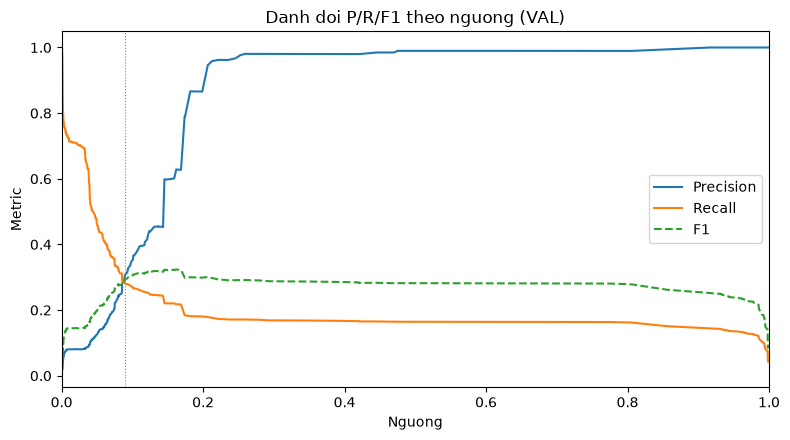

In [7]:
if best_model is not None and thr_choices is not None:
    try:
        import matplotlib.pyplot as plt

        order = np.argsort(thr_pr[:-1])
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.plot(thr_pr[:-1][order], prec[order], label="Precision")
        ax.plot(thr_pr[:-1][order], rec[order], label="Recall")
        ax.plot(thr_pr[:-1][order], f1[order], label="F1", ls="--")
        ax.axvline(CHOSEN_THRESHOLD, color="grey", lw=0.8, ls=":")
        ax.set_xlabel("Nguong")
        ax.set_ylabel("Metric")
        ax.set_xlim(0, 1)
        ax.set_title("Danh doi P/R/F1 theo nguong (VAL)")
        ax.legend()
        fig.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib unavailable; dung bang o tren.")
else:
    print("Skipped: enable RUN_TUNING above.")

## Kết luận notebook 11
- **Tuning** chọn tham số theo **PR-AUC trung bình trên walk-forward CV** (đúng bộ fold nb10), log mọi trial `stage=optuna`. Gain thường nhỏ → khớp kết luận "trần do feature/data".
- **Threshold** chốt ở điểm vận hành **FPR=1%** (0.5 là vô lý cho fraud mất cân bằng).
- **Bàn giao sang nb12:** `BEST_PARAMS` (Phần A) + `CHOSEN_THRESHOLD` (Phần B). nb12 mới mở TEST — đánh giá cuối + SHAP.
- Bản chốt promotable chạy `training/` với candidate matrix deterministic + manifest + đa seed (AGENTS §5/§6).